In this notebook, we will use sklearn's LASSO for feature selection. This serves to simplify our dataset and improve interpretability.

In [1]:
#dependencies
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.optimize import minimize # for ensemble weight optimization
#for feature selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LassoCV, LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [2]:
# download LightGBM package
!pip install lightgbm

In [3]:
# download catboost package
!pip install catboost

In [2]:
# LGBM & catboost dependencies
import lightgbm as lgbm
from catboost import CatBoostRegressor
#from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV

In [3]:
# function for model evalaution in both log-price 'units' as well as natural units (USD dollar) 
def evaluate_model(y_true, y_pred_log):

    # TRUE VALUES IN LOG SPACE
    y_true_log = np.log1p(y_true)

    # BACK TRANSFORM PREDICTIONS
    y_pred = np.expm1(y_pred_log)

    # --- METRICS IN LOG SPACE ---
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    r2_log = r2_score(y_true_log, y_pred_log)
    mape_log = mean_absolute_percentage_error(y_true_log, y_pred_log)

    # --- METRICS IN PRICE SPACE ---
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    print("------ LOG METRICS ------")
    print("RMSE_log:", rmse_log)
    print("MAE_log:", mae_log)
    print("R2_log:", r2_log)
    print("MAPE_log:", mape_log)

    print("\n------ PRICE METRICS ($) ------")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)
    print("MAPE:", mape)

    return

In [7]:
train = pd.read_csv("train.csv")
val = pd.read_csv("val.csv")

#drop unnecessary features
UnneededFeatures = ['sale_date.1', 'maker_name_maker', 'is_ambiguous', 'candidate_count', 'location_filled', 'date', 'usd', 'gbp', 'eur', 'lot','maker_name','role', 'Day', 'gbp_usd_y']
train = train.drop(columns = UnneededFeatures)
valid = val.drop(columns = UnneededFeatures)

X_train = train.iloc[:, train.columns != 'price_usd_real']
X_valid = valid.iloc[:, train.columns != 'price_usd_real']
Y_train = train.iloc[:, train.columns == 'price_usd_real']
Y_valid = valid.iloc[:, train.columns == 'price_usd_real']


In [8]:

#log transforming target
train['log_price'] = np.log1p(train['price_usd_real'])
t=train.groupby('type')['log_price']
# check if every type appears at least once in the train set 
print(t.count())
#groups each instrument type of the train set by its mean/median price
type_mean = t.mean()
type_median = t.median()

# It's fine, every type is represented in this training set even the rare ones, so we can proceed. Otherwise we'd need to fallback to the global mean.


type
Bass                45
Bass Bow           114
Bass Viol            6
Cello             1584
Cello Bow         2641
Miscellaneous        3
Small Violin       163
Tenor Viol           9
Treble Viol          8
Viola             1768
Viola Bow         1490
Viola d'Amore        3
Violin           14995
Violin Bow       10793
Name: log_price, dtype: int64


We will temporarily create two new columns in the validation set to predict the price of each instrument sale using our means/medians above.

In [6]:
#check for missing values
print(X_train['type'].isna().any())
print(X_valid['type'].isna().any())

#creating new columns
valid['type_mean']= valid['type'].map(type_mean)
valid['type_median'] = valid['type'].map(type_median)
valid.head()

False
False


,sale_date,maker_id,type,city_maker,auction_house,bold_currency,Year,Month,cpi_usd,cpi_gbp,...,10y_yield_90d_change,MCI,real_price_gold,country_iso1,admin1_name,admin2_name,maker_last_name,birth_cent,type_mean,type_median
0,2000-02-14,2827,Violin,Paris,Phillip's,gbp,2000,2,0.522057,0.534901,...,0.00505,-6.037718,588.0587,FR,Île-de-France,Paris,Collin-Mézin,20.0,9.159512,8.991187
1,1995-11-14,356,Violin,Mirecourt,Bonhams,gbp,1995,11,0.472249,0.493020,...,-0.00120,4.018622,815.9887,FR,Grand Est,Vosges,Thibouville-Lamy,19.0,9.159512,8.991187
2,2008-10-07,185,Cello,Mantua,Sotheby's,gbp,2008,10,0.665862,0.641440,...,-0.00420,-4.978523,1331.5068,IT,Lombardy,Provincia di Mantova,Gadda,20.0,10.124304,10.062779
3,1993-05-23,1327,Viola,Vienna,Skinner,usd,1993,5,0.443349,0.467303,...,-0.00440,1.206404,851.0234,AT,Vienna,Wien Stadt,Huber,18.0,9.097133,9.065886
4,2010-10-10,524,Violin,Cremona,Skinner,usd,2010,10,0.672436,0.665687,...,-0.00790,3.251219,2002.1250,IT,Lombardy,Provincia di Cremona,Pedrazzini,19.0,9.159512,8.991187


# Model 0: Mean & Median Baseline Models

In [9]:
#evaluating base model
print("Base model: Predicting prices by mean and median of train set \n")
print("Mean")
evaluate_model(Y_valid, valid['type_mean'])

print("\n Median")
evaluate_model(Y_valid, valid['type_median'])

Base model: Predicting prices by mean and median of train set 

Mean
------ LOG METRICS ------
RMSE_log: 1.285456313665743
MAE_log: 0.988432919402884
R2_log: 0.10001861657415356
MAPE_log: 0.11279419733674426

------ PRICE METRICS ($) ------
RMSE: 125935.18437162781
MAE: 22152.072084267635
R2: -0.014001477146394548
MAPE: 1.5594670219204665

 Median
------ LOG METRICS ------
RMSE_log: 1.2931641897639936
MAE_log: 0.9841738236638584
R2_log: 0.0891932891990842
MAPE_log: 0.11087921033874927

------ PRICE METRICS ($) ------
RMSE: 126116.55690583902
MAE: 22118.01709392209
R2: -0.016924321211996718
MAPE: 1.3814586533054676


It is clear that predicting fine string instrument prices based on their instrument type alone is really unsuccessful because there are so many characteristics/features that are not accounted for in this way, such as the maker who plays a hige role for the price, the instrument age, its condition, provenence and many more factors. An almost as crude baseline model, yet already more promising, is to predict for any sale of a given maker and type the mean or median of sales of instruments of this type and this maker where possible, otherwise fallback to the type mean.

In [9]:
def fit_baseline(train, min_count=1):
    """
    Compute mean prices on the training set.
    Returns three objects: maker_type_mean, type_mean, global_mean.
    min_count : minimum number of sales required to use the maker+type mean.
    """
    maker_type_stats = (
        train.groupby(['maker_id', 'type'])['log_price']
        .agg(['mean', 'count'])
    )
    maker_type_mean = (
        maker_type_stats[maker_type_stats['count'] >= min_count]['mean']
        .to_dict()
    )
    type_mean = t.mean().to_dict()

    return maker_type_mean, type_mean


def predict_baseline(df, maker_type_mean, type_mean):
    """
    For each row:
      1. Use the (maker_id, type) mean if >= min_count sales in train
      2. Otherwise use the type mean
    """
    preds = []
    for _, row in df.iterrows():
        key = (row['maker_id'], row['type'])
        if key in maker_type_mean:
            preds.append(maker_type_mean[key])
        elif row['type'] in type_mean:
            preds.append(type_mean[row['type']])
    return np.array(preds)

In [10]:
#  the prediction 
maker_type_mean, type_mean = fit_baseline(train)

y_pred = predict_baseline(valid, maker_type_mean, type_mean)

In [12]:
y_pred.min()

np.float64(5.201239254023125)

In [13]:
evaluate_model(Y_valid, y_pred)

------ LOG METRICS ------
RMSE_log: 0.7235277112568363
MAE_log: 0.5342694865235458
R2_log: 0.7148789897186255
MAPE_log: 0.06271652820481852

------ PRICE METRICS ($) ------
RMSE: 90880.64805801703
MAE: 13631.308149991059
R2: 0.47193515802333164
MAPE: 0.7896261917559948


In [ ]:
#dropping columns we created for base model
valid = valid.drop(columns = ['type_mean', 'type_median'])
train = train.drop(columns = ['log_price'])

In [15]:
#collect categorical features
CategoricalCols = train.select_dtypes(include=["object", "bool"]).columns.tolist()

for x in CategoricalCols:
    print(f"{x} has {train[x].nunique()} unique values")

sale_date has 941 unique values
maker_name has 3060 unique values
type has 14 unique values
city_maker has 628 unique values
auction_house has 27 unique values
lot has 1244 unique values
bold_currency has 3 unique values
country_iso1 has 37 unique values
admin1_name has 164 unique values
admin2_name has 371 unique values
role has 34 unique values
maker_last_name has 2164 unique values


C:\Users\Pierre\AppData\Local\Temp\ipykernel_18588\4058123389.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  CategoricalCols = train.select_dtypes(include=["object", "bool"]).columns.tolist()


We will consider features with less that 20 unique values as "low cardinality", and the rest as "high cardinality".

In [16]:
LowCardCols = ["type", "bold_currency"]
HighCardCols = ["sale_date", "maker_name", "city_maker", "auction_house", "lot", "country_iso1", "admin1_name", "admin2_name", "role", "maker_last_name"]

In [17]:
#log transforming economic features
LogColumns = ['real_price_gold', 'SP500_real']

In [18]:
#features with numerical values
numberdtype = X_train.select_dtypes(include=[np.number]).columns.tolist()

#prevent overlap
NumericalCols = list( set(numberdtype) - set(LogColumns))


In [19]:
#impute with median and scale numerical columns
Numerical_transformer = Pipeline([
     ('imputer', SimpleImputer(strategy='median')), 
     ('scaler', StandardScaler() )
     ])

#impute and one hot encode low cardinality columns
OneHot_transformer = Pipeline([
('imputer', SimpleImputer(strategy='constant', fill_value="other" )),
('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

#impute and target encode high cardinality columns
Target_transformer = Pipeline([
('imputer', SimpleImputer(strategy='constant', fill_value="other")),
('target', TargetEncoder() )
])

#transform "log columns"
log_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, feature_names_out="one-to-one") ),
    ('scale', StandardScaler())
])



In [20]:
#this will apply our transformations
preprocessor = ColumnTransformer(
    transformers =[
        ('lognum', log_transformer, LogColumns),
        ('lowcard', OneHot_transformer, LowCardCols ),
        ('highcard', Target_transformer, HighCardCols ) ,
        ('num', Numerical_transformer, NumericalCols )],
        remainder = 'passthrough',
        sparse_threshold=0
)

# Model 1: Lasso-Regression

We can fit our data to a lasso regression pipeline with the same transformed columns. We can use this with the goal of feature selection and determining feature importance.

In [21]:
#lassocv with 10 cross validation folds
pipeline_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', LassoCV(cv=10))
])


lr = pipeline_lasso.fit(X_train,np.log1p(Y_train))



c:\Users\Pierre\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Pierre\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [22]:
#predictions in log prices
lasso_pred = lr.predict(X_valid)

print("Lassocv model evaluation: \n")
evaluate_model(Y_valid, lasso_pred)


#gives the optimal penalty determined by lassocv
optimal_alpha = pipeline_lasso.named_steps['lasso'].alpha_
print("\nOptimal alpha:", f"{optimal_alpha:.5f}")


Lassocv model evaluation: 

------ LOG METRICS ------
RMSE_log: 0.6582702721995326
MAE_log: 0.5015098282579186
R2_log: 0.7639916504971732
MAPE_log: 0.058189382695606987

------ PRICE METRICS ($) ------
RMSE: 99132.77168741387
MAE: 13972.118896691018
R2: 0.37168284003907925
MAPE: 0.6489351433338368

Optimal alpha: 0.00126


In [23]:
#recovers the features transformed in the pipeline
preprocessor_lasso = pipeline_lasso.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

In [24]:
#gives coefficients used for each feature in regression
lasso_step = lr.named_steps['lasso']
coefficients = lasso_step.coef_

zerofeatures = []
nonzerofeatures = []

#setting a lower bound for a coefficient to be considered "nonzero"
epsilon = 1e-5

for i in range(len(feature_names)):
    if abs(coefficients[i]) < epsilon:
        zerofeatures.append(feature_names[i])
    else: nonzerofeatures.append(feature_names[i])

#the features with a coefficient of zero
for x in zerofeatures:
    print(x)


lowcard__type_Bass
lowcard__type_Bass Bow
lowcard__type_Bass Viol
lowcard__type_Miscellaneous
lowcard__type_Tenor Viol
lowcard__type_Treble Viol
lowcard__type_Viola Bow
lowcard__type_Viola d'Amore
lowcard__bold_currency_usd
num__SP500_30d_ret
num__gbp_vol_30d
num__gbp_usd_x
num__Year
num__SP500_trend_ratio
num__cpi_usd
num__SP500_vol_30d
num__SP500_ma200
num__Month


In [25]:
# feature and corresponding coefficient
lasso_coeffs = pd.DataFrame(index=feature_names, columns=['Lasso_Coeffs'])
lasso_coeffs.Lasso_Coeffs = coefficients
lasso_coeffs.loc[nonzerofeatures, :]

,Lasso_Coeffs
lognum__real_price_gold,-0.023433
lognum__SP500_real,0.021271
lowcard__type_Cello,0.813569
lowcard__type_Cello Bow,-0.040470
lowcard__type_Small Violin,-0.265840
lowcard__type_Viola,0.049996
lowcard__type_Violin,0.017985
lowcard__type_Violin Bow,-0.142087
lowcard__bold_currency_eur,-0.013120
lowcard__bold_currency_gbp,0.025972


In [26]:
#shows the different alphas selected by lassocv
alphas =lasso_step.alphas_
print(alphas)


[1.2555792  1.17095737 1.09203876 1.018439   0.94979962 0.88578631
 0.82608727 0.77041176 0.71848858 0.67006486 0.62490473 0.58278824
 0.54351026 0.50687949 0.47271751 0.44085793 0.41114558 0.38343575
 0.35759346 0.33349286 0.31101656 0.29005508 0.27050634 0.25227512
 0.23527262 0.21941603 0.20462813 0.19083687 0.17797511 0.16598018
 0.15479367 0.1443611  0.13463164 0.12555792 0.11709574 0.10920388
 0.1018439  0.09497996 0.08857863 0.08260873 0.07704118 0.07184886
 0.06700649 0.06249047 0.05827882 0.05435103 0.05068795 0.04727175
 0.04408579 0.04111456 0.03834357 0.03575935 0.03334929 0.03110166
 0.02900551 0.02705063 0.02522751 0.02352726 0.0219416  0.02046281
 0.01908369 0.01779751 0.01659802 0.01547937 0.01443611 0.01346316
 0.01255579 0.01170957 0.01092039 0.01018439 0.009498   0.00885786
 0.00826087 0.00770412 0.00718489 0.00670065 0.00624905 0.00582788
 0.0054351  0.00506879 0.00472718 0.00440858 0.00411146 0.00383436
 0.00357593 0.00333493 0.00311017 0.00290055 0.00270506 0.0025

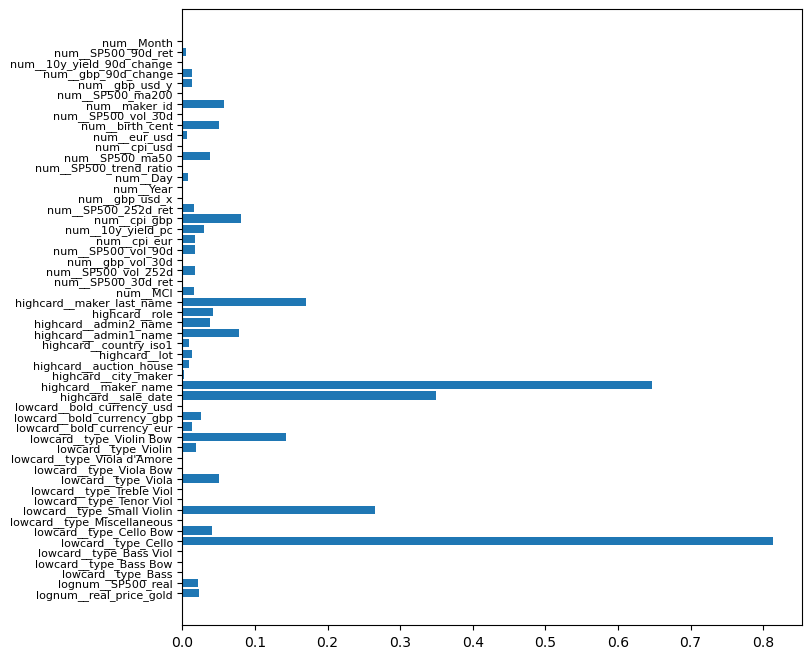

In [27]:
plt.figure(figsize=(8,8))

abs_coefficients = [abs(x) for x in coefficients]
plt.barh(feature_names, abs_coefficients)
plt.tight_layout
plt.yticks(fontsize=8)
plt.show()

Here we see that many different features all carry predictive power: the instrument type is especially crucial for price prediction bt so is the instrument maker. In addition to that the enhanced features that were created especially for this data set seem to have good predictive power. Those are the economic features based, e.g., on the stock market indices, as well as the geographical information inferred for each instrument.

# Model 2: Random Forest

In [28]:
#creates a pipeline object
pipeline_randomforest = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(n_estimators=200, random_state=0))
])
#fits our data to the pipeline/model with log transformed target
rf = pipeline_randomforest.fit(X_train,np.log1p(Y_train))

forest_pred = rf.predict(X_valid)

evaluate_model(Y_valid, forest_pred)

c:\Users\Pierre\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Pierre\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


------ LOG METRICS ------
RMSE_log: 0.6186946475485535
MAE_log: 0.4679437936187928
R2_log: 0.7915165427495499
MAPE_log: 0.05434937332937295

------ PRICE METRICS ($) ------
RMSE: 73442.7977844547
MAE: 11930.596416172604
R2: 0.6551399802762712
MAPE: 0.5933398609521415


# Model 3: LightGBM

Define the Model with default parameters.

In [29]:
lgbm_model = lgbm.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose = -1
)

In [30]:
pipeline_lgbm = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgbm_model)])

Use cross-validation to find the best model via a grid-search.

In [31]:
'''param_grid = {
    "model__num_leaves": [80, 100, 120, 140],
    "model__learning_rate": [0.005, 0.007, 0.009],
    "model__n_estimators": [800, 900, 1000],
    "model__max_depth": [-1]
}'''
# this parameter grid has already been narrowed down in many iterations of running the algo
param_grid = {
    "model__num_leaves": [62, 63, 64], # best 63
    "model__learning_rate": [0.01, 0.011], # best 0.011
    "model__n_estimators": [2300, 2500, 2700, 2900], # best 2300
    "model__max_depth": [-1]
}


search_lgbm = RandomizedSearchCV(
    pipeline_lgbm,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_iter=20,
    n_jobs=-1,
    verbose=1
)

In [32]:
search_lgbm.fit(X_train, np.log1p(Y_train.values.ravel()))

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...verbose=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.011], 'model__max_depth': [-1], 'model__n_estimators': [2300, 2500, ...], 'model__num_leaves': [62, 63, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation s

In [33]:
best_lgbm = search_lgbm.best_estimator_
print(search_lgbm.best_params_)

{'model__num_leaves': 63, 'model__n_estimators': 2900, 'model__max_depth': -1, 'model__learning_rate': 0.01}


### Prediction

In [34]:
y_pred_log_lgbm = best_lgbm.predict(X_valid)
#y_pred_lgbm = np.expm1(y_pred_log_lgbm)

c:\Users\Pierre\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [35]:
evaluate_model(Y_valid, y_pred_log_lgbm)

------ LOG METRICS ------
RMSE_log: 0.5935816168072622
MAE_log: 0.45039496741551655
R2_log: 0.8080978823005014
MAPE_log: 0.05234126057733949

------ PRICE METRICS ($) ------
RMSE: 86569.12910186675
MAE: 12076.667149536841
R2: 0.5208510729696267
MAPE: 0.5682360127176994


In [36]:
# 

# Model 4: CatBoost

In [37]:
y_train_log = np.log1p(Y_train.squeeze())
y_valid_log = np.log1p(Y_valid.squeeze())

cat_model = CatBoostRegressor(
    loss_function='RMSE',
    random_seed=42,
    verbose=0)

pipeline_cat = Pipeline([("preprocessor", preprocessor), ("model", cat_model)])

'''param_dist = {
    "model__iterations": [2000,3000,4000], #best was 2000
    "model__learning_rate": [0.01,0.02,0.03], #best was 0.03
    "model__depth": [10, 12, 15], #best was 10
    "model__l2_leaf_reg": [20], #best was 20
    "model__min_data_in_leaf": [5], #best was 5
}'''
param_dist = {
    "model__iterations": [2000], #best was 2000
    "model__learning_rate": [0.03], #best was 0.03
    "model__depth": [10], #best was 10
    "model__l2_leaf_reg": [20], #best was 20
    "model__min_data_in_leaf": [5], #best was 5
}

search_cat = RandomizedSearchCV(
    pipeline_cat,
    param_distributions=param_dist,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_iter=20,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [38]:
search_cat.fit(X_train, y_train_log)

best_cat = search_cat.best_estimator_
print("Best CatBoost params:", search_cat.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\Pierre\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 1 is smaller than n_iter=20. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\Pierre\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Pierre\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_par

Best CatBoost params: {'model__min_data_in_leaf': 5, 'model__learning_rate': 0.03, 'model__l2_leaf_reg': 20, 'model__iterations': 2000, 'model__depth': 10}


In [39]:
y_pred_log_cat = best_cat.predict(X_valid)

evaluate_model(Y_valid.squeeze(), y_pred_log_cat)

------ LOG METRICS ------
RMSE_log: 0.5905398569634103
MAE_log: 0.44814650220025126
R2_log: 0.8100596160411754
MAPE_log: 0.05214992349859159

------ PRICE METRICS ($) ------
RMSE: 86530.6929977575
MAE: 11911.490646312695
R2: 0.5212764562397985
MAPE: 0.5645656208248068


# Model(s) 5: Ensemble Method
In this section we will combine (in various ways) the predictions of the three performant model (Random Forest, LGBM, CatBoost) in order to determine whether a combination of the models performs better than each one alone.

In [40]:
# stack all the predictions that ought be used in the ensemble
X_ensemble = np.column_stack([
    forest_pred,
    y_pred_log_lgbm,
    y_pred_log_cat
])

## Naive Ensemble

In [41]:
y_pred_avg = X_ensemble.mean(axis=1)

In [42]:
evaluate_model(Y_valid, y_pred_avg)

------ LOG METRICS ------
RMSE_log: 0.5919821070684487
MAE_log: 0.4482370124800803
R2_log: 0.8091307166508869
MAPE_log: 0.052121592447829816

------ PRICE METRICS ($) ------
RMSE: 82403.37908974005
MAE: 11794.036863520067
R2: 0.5658553384540379
MAPE: 0.5646448606500584


## Weighted Ensemble
We find the optimal ensemble weights via optimization with a RMSE loss for weighting the models linearly, which is implemented through an additional Ridge Regression. This means the ensemble prediction is a omptimized linear combination of the 3 input model predictions. 

In [43]:
def rmse_loss(weights):
    weights = weights / weights.sum()  # normalize weights, such that they sum to 1
    y_pred = np.dot(X_ensemble, weights)
    return np.sqrt(mean_squared_error(y_valid_log, y_pred))

# initial equal weights
init_weights = np.array([1/3, 1/3, 1/3])

# constraint: weights sum to 1
constraints = {'type': 'eq', 'fun': lambda w: w.sum() - 1}

# bounds: weights between 0 and 1
bounds = [(0, 1)] * 3

result = minimize(rmse_loss, init_weights, bounds=bounds, constraints=constraints) # scipy numerical optimizer

optimal_weights = result.x / result.x.sum()
print("Optimal weights:", optimal_weights)

Optimal weights: [0.02001516 0.37105589 0.60892895]


In [44]:
meta_model = Ridge(alpha=1)
meta_model.fit(X_ensemble, y_valid_log)

y_pred_stacked = meta_model.predict(X_ensemble)

print("Stacking coefficients:", meta_model.coef_)

Stacking coefficients: [0.02561564 0.3731472  0.61383278]


In [45]:
evaluate_model(Y_valid, y_pred_stacked)

------ LOG METRICS ------
RMSE_log: 0.5884424617022938
MAE_log: 0.44621828716249207
R2_log: 0.8114064264275422
MAPE_log: 0.05188117335873086

------ PRICE METRICS ($) ------
RMSE: 84541.45276895282
MAE: 11749.662581048666
R2: 0.5430340547880419
MAPE: 0.5606354471370183
